# Time on Tech

# Introduction

My name is Darrell Cenido and I will analyzing the time I spend on my phone over that past 3 months. I wanted to explore this domain because I wanted to know how much time I was wasting using my phone. I felt like I was using my phone excessively especially over winter break and wanted to limit this use. The dataset is from my own manually crafted csv file with information from my screen time tab in my iPhone settings. In this dataset we have 75 instances over the past 3 months. The attributes in this dataset are the date, day of the week, total screen time that day in minutes, my most used app that day, time spent using my top app, and the hour of the day that I was on my phone the most. I chose to include the day of the week because I thought it would be interesting to see what days I spend the most time on my phone. I included total screen time as well because there are only limited hours in a day and this is how much I am spending on my phone. My most used app tells me which app the majority of my screen time was spent on. I also included how much time I spend on my top app in a day. And my final statistic that I included was the hour of the day I was on my phone the most because I wanted to see what time I should try not to use my phone as much. From my results I will know what time of the day I am on my phone the most and what apps I use the most. With this information I can benefit and set time limits accordingly to decrease my total screentime.

# Data Preparation
* This is my screen time over most of this semester from 01/26/25 - 04/10/25
* I used the data from my screen time in settings and typed it into my own csv file
* There were no missing values in this dataset because I manually created this csv file
* Originally screen time was listed as hours and minutes but I manually cleaned this data and calculated the total in minutes
    * I did the same for amount of time spent using my top app as well
* When I first attempted to make this csv file earlier in the year I had spaces between each set of data
    * After around an hour of coding I realized how this small issue caused the whole program to fail

In [55]:
import pandas as pd

df = pd.read_csv('screentime.csv')
print(df)

        Date Day of Week  Screen Time (min) Most Used App  \
0   01/26/25      Sunday                176     Instagram   
1   01/27/25      Monday                103      Snapchat   
2   01/28/25     Tuesday                 84     Instagram   
3   01/29/25   Wednesday                307      Snapchat   
4   01/30/25    Thursday                306     Instagram   
..       ...         ...                ...           ...   
70  04/06/25      Sunday                115     Instagram   
71  04/07/25      Monday                287     Instagram   
72  04/08/25     Tuesday                127     Instagram   
73  04/09/25   Wednesday                214        Tiktok   
74  04/10/25    Thursday                265     Instagram   

    Time on Top App (min)  Hour with Most Screen Time (0-24 Military Time)  
0                     138                                               20  
1                      74                                               14  
2                      41           

# Exploratory Data Analysis

* I originally thought that my time spent on my phone during weekends would be siginificantly more that during the week so I decided to illustrate this with a graph

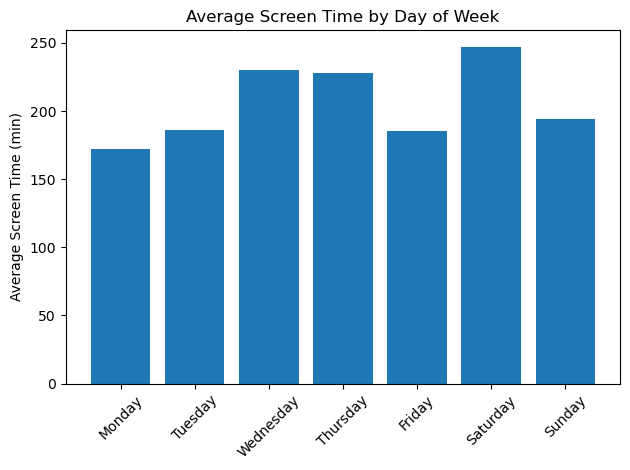

In [56]:
import matplotlib.pyplot as plt

avg_by_day = df.groupby('Day of Week')['Screen Time (min)'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

days = avg_by_day.index
averages = avg_by_day.values

plt.bar(days, averages)
plt.title('Average Screen Time by Day of Week')
plt.ylabel('Average Screen Time (min)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From this graph we can already see that Saturday appears to be the day that I average the most screen time which makes a lot of sense considering it is the weekend and I don't have school the next day.

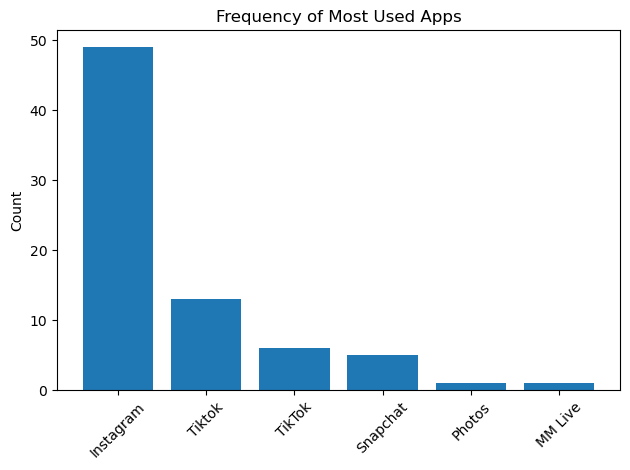

In [57]:
app_counts = df['Most Used App'].value_counts()

apps = app_counts.index
counts = app_counts.values

plt.bar(apps, counts)
plt.title('Frequency of Most Used Apps')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

From this Frequency of Most Used Apps bar graph you can see that Instagram is the app that I tend to use most frequently. If I am trying to limit my screen time I should definitely use a time limit app should as Opal. It is an app I found that can set a strict time limit and block you from opening an app. You can block only specific apps from any timeblock during the day.

/var/folders/l8/v_lmv8vd5rl7fryk24lk_s7c0000gn/T/ipykernel_95246/2240973705.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


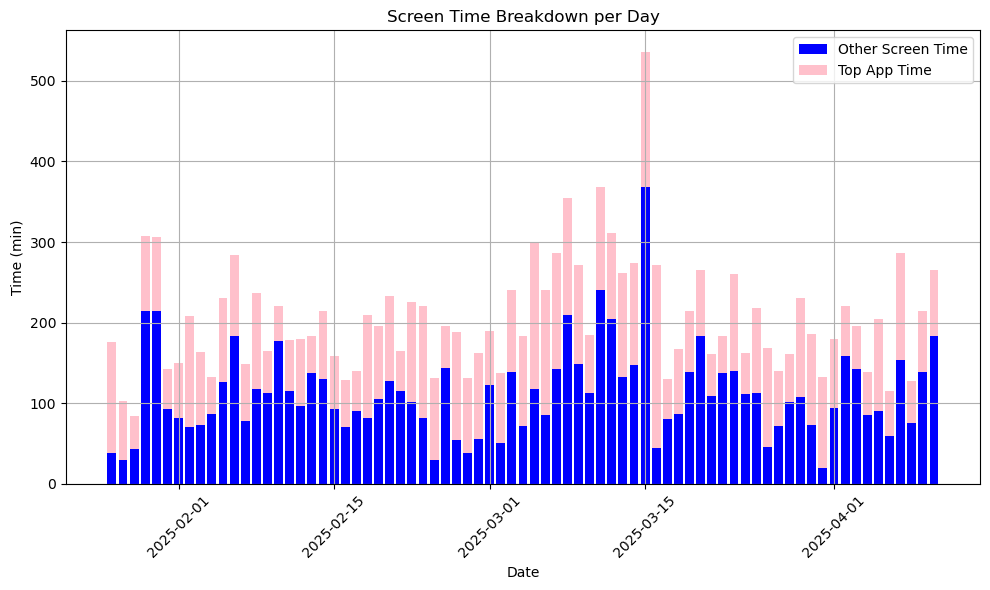

In [58]:
import numpy as np

df['Date'] = pd.to_datetime(df['Date'])

daily_screen_time = df.groupby(df['Date'].dt.date)['Screen Time (min)'].sum()
daily_top_app_time = df.groupby(df['Date'].dt.date)['Time on Top App (min)'].sum()

dates = daily_screen_time.index
x = np.arange(len(dates))
width = 0.4

plt.figure(figsize=(10, 6))
plt.bar(dates, daily_screen_time - daily_top_app_time, label='Other Screen Time', color='blue')
plt.bar(dates, daily_top_app_time, bottom=daily_screen_time - daily_top_app_time, label='Top App Time', color='pink')

plt.title('Screen Time Breakdown per Day')
plt.xlabel('Date')
plt.ylabel('Time (min)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

From this graph we can see that my time spent on my top app tends to take up most of my screen time. I need to be able to limit my time on a specific app, Instagram in most cases, in order to cut down on my screen time.

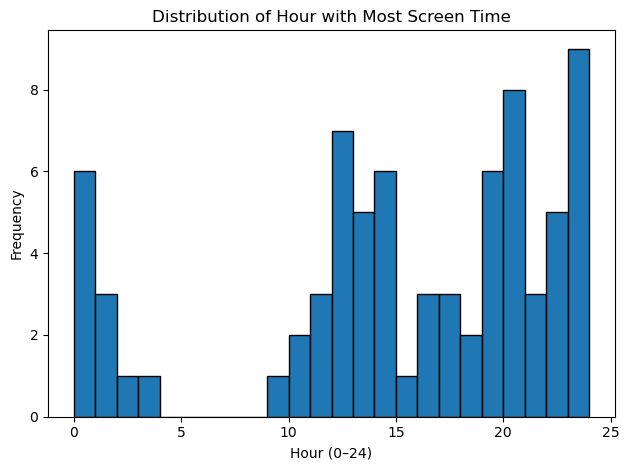

In [59]:
plt.hist(df['Hour with Most Screen Time (0-24 Military Time)'], bins=24, edgecolor='black')
plt.title('Distribution of Hour with Most Screen Time')
plt.xlabel('Hour (0–24)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

One thing I noticed about this graph is that the hours of the day that I tend to use my phone the most are when I eat meals and when I am about to go to sleep. If I use the Opal app that i mentioned previosly then I can prevent his from happening.

# Hypothesis Testing

# 1. Two-sample, **one-tailed** t-test of the population means

1. 
    * $h_{0}: M_{weekend} \leq M_{weekday}$
    * $h_{1}: M_{weekend} > M_{weekday}$
2. 
    * $\alpha = 0.025$
3. 
    * t = $\frac{\overline{X_{1}} - \overline{X_{2}}}{\sqrt{(s_{p})^{2}(\frac{1}{n_{1}} + \frac{1}{n_{2}})}}$
4. 
    * df = 75 - 2 = 73
    * t-critical = 2.000
    * if $t_{comp}$ < 2.000 reject $h_{0}$
5. 
    * $t_{comp}$ = 0.839
    * Since $t_{comp}$ (0.839) < 2.000 then do not reject $h_{0}$
    * At the 0.025 level of significance, weekend screen time is not significantly greater than weekday screen time.

In [60]:
# Check with Scipy
import scipy.stats as stats
import numpy as np

avg_by_weekend = df.groupby('Day of Week')['Screen Time (min)'].mean().reindex(
    ['Saturday', 'Sunday'])

avg_by_weekday = df.groupby('Day of Week')['Screen Time (min)'].mean().reindex(
    ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday'])

# Check with Numpy
# two sample, one-tailed independent test of means
Xbar_exp = np.mean(avg_by_weekend)
print("Exp Mean: ", Xbar_exp)
Xbar_cont = np.mean(avg_by_weekday)
print("Cont Mean: ", Xbar_cont)
s_exp = np.std(avg_by_weekend, ddof=1)
s_cont = np.std(avg_by_weekday, ddof=1)
n_exp = len(avg_by_weekend)
n_cont = len(avg_by_weekday)

# pooled variance
sp2 = ((n_exp - 1) * s_exp ** 2 + (n_cont - 1) * s_cont ** 2) / (n_exp + n_cont - 2)
print("SP2: ", sp2)
t_computed = (Xbar_exp - Xbar_cont) / np.sqrt(sp2 * (1 / n_exp + 1 / n_cont))
print("t computed:", t_computed)

t_computed, p_val = stats.ttest_ind(avg_by_weekend, avg_by_weekday)
# when performing a one tailed test, you need to divide the pval by 2
p_val /= 2
print("scipy t computed:", t_computed, "p val:", p_val)
alpha = 0.025
if p_val < alpha:
    print("Reject H0")
else:
    print("Do not reject H0")


Exp Mean:  220.67727272727274
Cont Mean:  200.28
SP2:  845.3549305785122
t computed: 0.8385009090052845
scipy t computed: 0.8385009090052846 p val: 0.2199910166710592
Do not reject H0


# 2. Two-sample, **one-tailed** t-test of the population means

1. 
    * $h_{0}: M_{high} \leq M_{low}$
    * $h_{1}: M_{high} > M_{low}$
2. 
    * $\alpha = 0.025$
3. 
    * t = $\frac{\overline{X_{1}} - \overline{X_{2}}}{\sqrt{(s_{p})^{2}(\frac{1}{n_{1}} + \frac{1}{n_{2}})}}$
4. 
    * df = 75 - 2 = 73
    * t-critical = 2.000
    * if $t_{comp}$ < 2.000 reject $h_{0}$
5. 
    * $t_{comp}$ = 6.099
    * Since $t_{comp}$ (6.0999) < 2.000 then do not reject $h_{0}$
    * At the 0.025 level of significance, those who used their top app more had significantly greater screentime than those who used their top app less.

In [61]:
df["High Screen Time"] = (df["Screen Time (min)"] > 200).astype(int)

# Separate into groups
high = df[df["High Screen Time"] == 1]["Time on Top App (min)"]
low = df[df["High Screen Time"] == 0]["Time on Top App (min)"]


# Check with Numpy
# two sample, one-tailed independent test of means
Xbar_exp = np.mean(high)
print("Exp Mean: ", Xbar_exp)
Xbar_cont = np.mean(low)
print("Cont Mean: ", Xbar_cont)
s_exp = np.std(high, ddof=1)
s_cont = np.std(low, ddof=1)
n_exp = len(high)
n_cont = len(low)

# pooled variance
sp2 = ((n_exp - 1) * s_exp ** 2 + (n_cont - 1) * s_cont ** 2) / (n_exp + n_cont - 2)
print("SP2: ", sp2)
t_computed = (Xbar_exp - Xbar_cont) / np.sqrt(sp2 * (1 / n_exp + 1 / n_cont))
print("t computed:", t_computed)

t_computed, p_val = stats.ttest_ind(high, low)
# when performing a one tailed test, you need to divide the pval by 2
p_val /= 2
print("scipy t computed:", t_computed, "p val:", p_val)
alpha = 0.025
if p_val < alpha:
    print("Reject H0")
else:
    print("Do not reject H0")


Exp Mean:  117.1470588235294
Cont Mean:  73.58536585365853
SP2:  948.0577524026647
t computed: 6.09941393975831
scipy t computed: 6.099413939758309 p val: 2.3125879130545263e-08
Reject H0


# Classification Results

In [62]:
df["High Screen Time"] = (df["Screen Time (min)"] > 200).astype(int)

X_train = df[["Time on Top App (min)", "Hour with Most Screen Time (0-24 Military Time)"]]
y_train = df["High Screen Time"]
print(X_train)
print(y_train)

    Time on Top App (min)  Hour with Most Screen Time (0-24 Military Time)
0                     138                                               20
1                      74                                               14
2                      41                                               21
3                      93                                               19
4                      91                                                1
..                    ...                                              ...
70                     56                                               11
71                    134                                               14
72                     52                                                0
73                     75                                               19
74                     82                                               22

[75 rows x 2 columns]
0     0
1     0
2     0
3     1
4     1
     ..
70    0
71    1
72    0
73   

In [68]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Fit the scaler
scaler = MinMaxScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
print(X_train_scaled)

feature_means = np.mean(X_train, axis=0)

X_test = [[100, 14]]

X_test_scaled = scaler.transform(X_test)
print(X_test_scaled)

[[0.8943662  0.13043478]
 [0.45774648 1.        ]
 [0.31690141 0.95652174]
 [0.23943662 0.82608696]
 [0.65492958 0.60869565]
 [0.42957746 0.60869565]
 [0.35211268 0.04347826]
 [0.45774648 0.52173913]
 [0.12676056 0.73913043]
 [0.16901408 0.52173913]
 [0.20422535 0.56521739]
 [0.68309859 0.86956522]
 [0.21830986 0.04347826]
 [0.27464789 0.69565217]
 [0.35211268 0.73913043]
 [0.06338028 0.69565217]
 [0.57746479 0.        ]
 [0.57746479 0.47826087]
 [0.28873239 0.95652174]
 [0.6056338  0.60869565]
 [0.06338028 0.43478261]
 [0.61267606 0.60869565]
 [0.72535211 1.        ]
 [0.35211268 0.7826087 ]
 [0.30985915 0.86956522]
 [0.28873239 0.95652174]
 [0.54929577 0.60869565]
 [0.         0.91304348]
 [0.14788732 0.56521739]
 [0.07746479 0.95652174]
 [0.06338028 0.52173913]
 [0.36619718 0.91304348]
 [0.49295775 0.7826087 ]
 [0.1056338  0.47826087]
 [0.50704225 0.86956522]
 [0.57746479 1.        ]
 [0.07746479 0.82608696]
 [0.12676056 0.82608696]
 [0.03521127 0.82608696]
 [1.         0.86956522]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [75]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier(n_neighbors=10, metric="euclidean")
# build/train
knn_clf.fit(X_train_scaled, y_train)
# predict
y_predicted = knn_clf.predict(X_test_scaled)
print(y_predicted)

# challenge: can you print out the neighbor distances?
distances, indices = knn_clf.kneighbors(X_test_scaled)
print("Distances to nearest neighbors:", distances)

[0]
Distances to nearest neighbors: [[0.01408451 0.09381508 0.09667883 0.12077356 0.13380282 0.14501825
  0.16552574 0.18309859 0.18510215 0.19007156]]


In [76]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Make sure you're splitting the data first
X_train, X_test, y_train, y_test = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=42
)

# Refit the model on the training set
knn_clf.fit(X_train, y_train)

# Predict on the test set
y_pred = knn_clf.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("KNN Accuracy:", accuracy)

KNN Accuracy: 0.6666666666666666


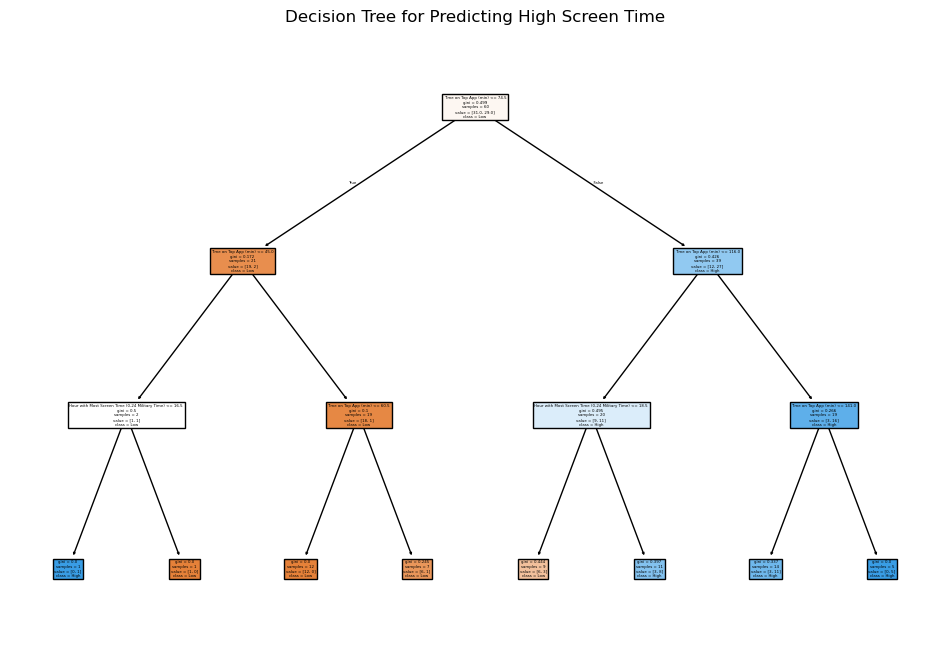

Decision Tree Accuracy: 0.6666666666666666


In [77]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

X = df[["Time on Top App (min)", "Hour with Most Screen Time (0-24 Military Time)"]]
y = df["High Screen Time"]

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=17, test_size=0.2)

dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

plt.figure(figsize=(12, 8))
plot_tree(dt, feature_names=X.columns, class_names=['Low', 'High'], filled=True)
plt.title("Decision Tree for Predicting High Screen Time")
plt.show()

y_pred = dt.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Decision Tree Accuracy:", accuracy)


# Conclusion

My data shows that the more time I spend on my top app, the higher my overall screen time tends to be. This relationship is both strong and statistically significant. In this case, the top app was often Instagram, suggesting that it's a major contributor to my overall phone usage. While the classification model I built was able to separate high and low screen time based on app usage and time of day, if I were to redo this project I would have chosen a more complex or varied dataset to explore classification more in depth. This project was valuable in revealing how a single app can dominate my screen time habits. Moving forward, if I want to reduce my screen time and setting limits on Instagram seems like the best plan moving forward.